Final predicted output:
[[0.06368082]
 [0.94085536]
 [0.94108726]
 [0.06402009]]

Rounded output:
[[0.]
 [1.]
 [1.]
 [0.]]

Final W1:
[[3.61819073 5.77402875]
 [3.60479109 5.70602856]]

Final b1:
[[-5.52792904 -2.37674101]]

Final W2:
[[-7.94768935]
 [ 7.31108691]]

Final b2:
[[-3.27790773]]


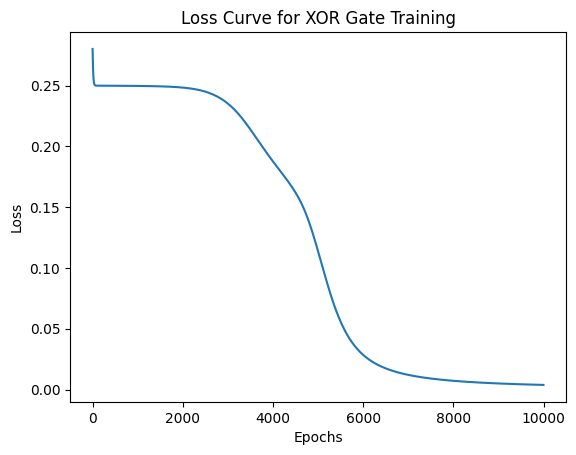

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Sigmoid activation
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Sigmoid derivative
def sigmoid_derivative(a):
    return a * (1 - a)

# XOR inputs
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

# XOR actual outputs
y = np.array([
    [0],
    [1],
    [1],
    [0]
])

np.random.seed(1)

# -----------------------------
# Weights from Input → Hidden
# -----------------------------
# W1 =
# [[w11, w12],
#  [w21, w22]]
W1 = np.random.uniform(size=(2, 2))

# Bias for hidden neurons
# b1 = [b_h1, b_h2]
b1 = np.random.uniform(size=(1, 2))

# -----------------------------
# Weights from Hidden → Output
# -----------------------------
# W2 =
# [[w31],
#  [w41]]
W2 = np.random.uniform(size=(2, 1))

# Bias for output neuron
b2 = np.random.uniform(size=(1, 1))

epochs = 10000
learning_rate = 0.1
losses = []

for epoch in range(epochs):

    # =============================
    # Forward Propagation
    # =============================

    # Hidden layer input:
    # z_hidden = X.W1 + b1
    z_hidden = np.dot(X, W1) + b1

    # Hidden layer output:
    # a_hidden = sigmoid(z_hidden)
    a_hidden = sigmoid(z_hidden)

    # Output layer input:
    # z_output = a_hidden.W2 + b2
    z_output = np.dot(a_hidden, W2) + b2

    # Final predicted output:
    # y_hat = sigmoid(z_output)
    y_hat = sigmoid(z_output)

    # =============================
    # Loss Calculation
    # =============================

    error = y - y_hat

    loss = np.mean(np.square(error))
    losses.append(loss)

    # =============================
    # Backpropagation
    # =============================

    # Output layer delta:
    # delta_output = error * sigmoid'(y_hat)
    delta_output = error * sigmoid_derivative(y_hat)

    # Hidden layer error:
    # error_hidden = delta_output . W2^T
    error_hidden = delta_output.dot(W2.T)

    # Hidden layer delta:
    # delta_hidden = error_hidden * sigmoid'(a_hidden)
    delta_hidden = error_hidden * sigmoid_derivative(a_hidden)

    # =============================
    # Weight Updates
    # =============================

    # W2 = W2 + learning_rate * a_hidden^T . delta_output
    W2 += a_hidden.T.dot(delta_output) * learning_rate

    # b2 = b2 + learning_rate * sum(delta_output)
    b2 += np.sum(delta_output, axis=0, keepdims=True) * learning_rate

    # W1 = W1 + learning_rate * X^T . delta_hidden
    W1 += X.T.dot(delta_hidden) * learning_rate

    # b1 = b1 + learning_rate * sum(delta_hidden)
    b1 += np.sum(delta_hidden, axis=0, keepdims=True) * learning_rate


print("Final predicted output:")
print(y_hat)

print("\nRounded output:")
print(np.round(y_hat))

print("\nFinal W1:")
print(W1)

print("\nFinal b1:")
print(b1)

print("\nFinal W2:")
print(W2)

print("\nFinal b2:")
print(b2)

plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve for XOR Gate Training")
plt.show()